### import libraries 

In [1]:
! pip install torch torchvision tqdm torchsummary

In [2]:
import torch 
import torchvision
import torch.nn as nn 
import tqdm
from torch.nn import functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm  # Specialized for Kaggle/Jupyter

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/dollyprajapati182
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/fear
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/angry
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/neutral
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/sad
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/disgust
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/happy
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/test
/kaggle/input/datasets/dollyprajapati18

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Define dataset paths - make transform ready to use in dataloader 

In [4]:

# Define the paths based on the Kaggle input directory
BASE_DIR = '/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale'

# The folder structure in that specific dataset usually repeats the folder name
train_path = os.path.join(BASE_DIR, 'train')
val_path = os.path.join(BASE_DIR, 'val')
test_path = os.path.join(BASE_DIR, 'test')

# Transformation: Convert to Grayscale (1 channel) and then to Tensor (Normalize to 0-1)
data_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

In [5]:
# Load the datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transforms)
val_dataset = datasets.ImageFolder(root=val_path, transform=data_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=data_transforms)
 
# Create the DataLoaders
# 'num_workers' uses multi-processing to load data faster
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=2)

# Get class names (e.g., ['angry', 'disgust', 'fear', ...])
class_names = train_dataset.classes
print(f"Detected Classes: {class_names}")
print(f"Training images: {len(train_dataset)}")
print(f"validation images: {len(val_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Detected Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training images: 30023
validation images: 7504
Testing images: 4165


In [6]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        # Block 1: Input 75x75x1 -> Output 37x37x32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2: Input 37x37x32 -> Output 18x18x64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3: Input 18x18x64 -> Output 9x9x128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Block 4: Input 9x9x128 -> Output 4x4x256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        # 4*4*256 = 4096 features after flattening
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5) # Prevents overfitting
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        
        x = x.view(-1, 256 * 4 * 4) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize and move to GPU
model = EmotionCNN(num_classes=7).to(device)

In [7]:
print(model)

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilat

In [8]:
import torch.optim as optim
from tqdm.notebook import tqdm

# 1. The Judge: CrossEntropyLoss is standard for multi-class (7 emotions)
criterion = nn.CrossEntropyLoss()

# 2. The Brain: Adam optimizer is great for CNNs
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Function
def train_model(epochs=50):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # tqdm progress bar
        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', unit='batch')
        
        for images, labels in loop:
            # CRITICAL: Move your data to the 'device' (GPU)
            images, labels = images.to(device), labels.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass (Learning)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            loop.set_postfix(loss=(running_loss/len(train_loader)))

    print("Training Complete!")

# Start the training
train_model(epochs=50)

Epoch 1/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 2/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 3/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 4/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 5/50:   0%|          | 0/470 [00:00<?, ?batch/s]

...

Epoch 47/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 48/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 49/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Epoch 50/50:   0%|          | 0/470 [00:00<?, ?batch/s]

Training Complete!


### Validation

In [9]:
def validate(model, loader, criterion):
    # 1. Set to evaluation mode
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    total_samples = 0
    
    # 2. Disable gradient calculation to save memory and speed up
    with torch.no_grad():
        # tqdm for visual progress
        loop = tqdm(loader, desc="Validating", unit="batch")
        
        for images, labels in loop:
            # Move data to GPU (Tesla T4)
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Update metrics
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            total_samples += labels.size(0)
            
            # Update progress bar
            loop.set_postfix(loss=loss.item())

    # 3. Final calculations
    avg_loss = val_loss / len(loader)
    accuracy = (val_correct / total_samples) * 100
    
    print(f"\n" + "="*30)
    print(f"Validation Results:")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Accuracy:     {accuracy:.2f}%")
    print("="*30)
    
    return avg_loss, accuracy

# Execute the validation
current_val_loss, current_val_acc = validate(model, val_loader, criterion)

Validating:   0%|          | 0/118 [00:00<?, ?batch/s]


Validation Results:
Average Loss: 0.4762
Accuracy:     91.70%


# test new data 

In [10]:
import PIL.Image as Image

# 1. Path to your image
image_path = ""
# 2. Pre-process the image (Must match your model's training input)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((75, 75)),
    transforms.ToTensor(),
])

'''
# 3. Load and prepare the tensor
img = Image.open(image_path)
img_tensor = transform(img)         # Shape: [1, 75, 75]
img_tensor = img_tensor.unsqueeze(0) # Shape: [1, 1, 75, 75] (Batch, Channel, H, W)

# 4. Move to GPU and Predict
model.eval()
with torch.no_grad():
    output = model(img_tensor.to(device))
    _, pred = torch.max(output, 1)

# 5. Result
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print(f"The model predicts: {classes[pred.item()]}")'''

'\n# 3. Load and prepare the tensor\nimg = Image.open(image_path)\nimg_tensor = transform(img)         # Shape: [1, 75, 75]\nimg_tensor = img_tensor.unsqueeze(0) # Shape: [1, 1, 75, 75] (Batch, Channel, H, W)\n\n# 4. Move to GPU and Predict\nmodel.eval()\nwith torch.no_grad():\n    output = model(img_tensor.to(device))\n    _, pred = torch.max(output, 1)\n\n# 5. Result\nclasses = [\'angry\', \'disgust\', \'fear\', \'happy\', \'neutral\', \'sad\', \'surprise\']\nprint(f"The model predicts: {classes[pred.item()]}")'

Predicting for Confusion Matrix:   0%|          | 0/66 [00:00<?, ?it/s]

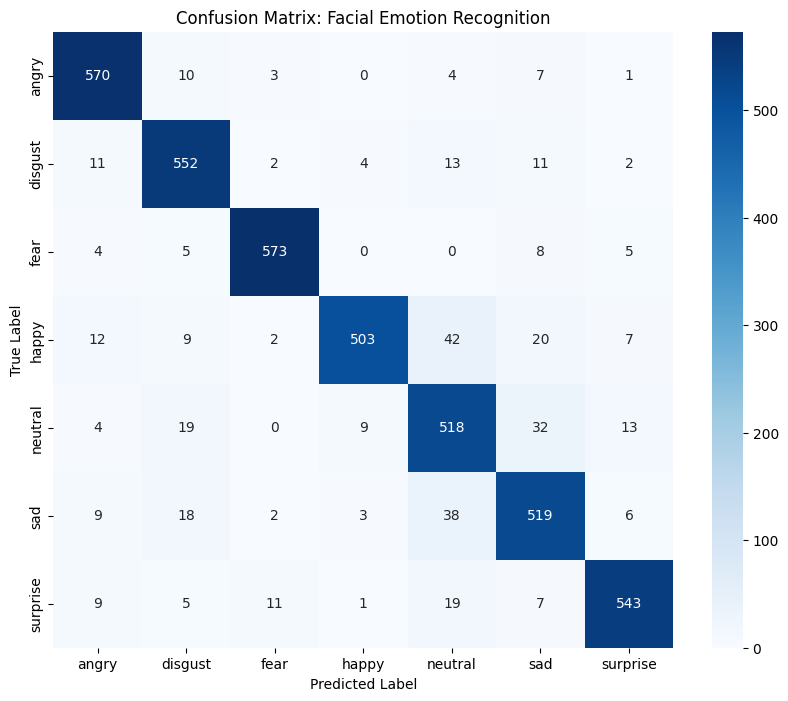


Classification Report:

              precision    recall  f1-score   support

       angry       0.92      0.96      0.94       595
     disgust       0.89      0.93      0.91       595
        fear       0.97      0.96      0.96       595
       happy       0.97      0.85      0.90       595
     neutral       0.82      0.87      0.84       595
         sad       0.86      0.87      0.87       595
    surprise       0.94      0.91      0.93       595

    accuracy                           0.91      4165
   macro avg       0.91      0.91      0.91      4165
weighted avg       0.91      0.91      0.91      4165



In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting for Confusion Matrix"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Create the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Facial Emotion Recognition')
    plt.show()

    # Bonus: Print a detailed classification report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Run the plot
plot_confusion_matrix(model, test_loader, train_dataset.classes)

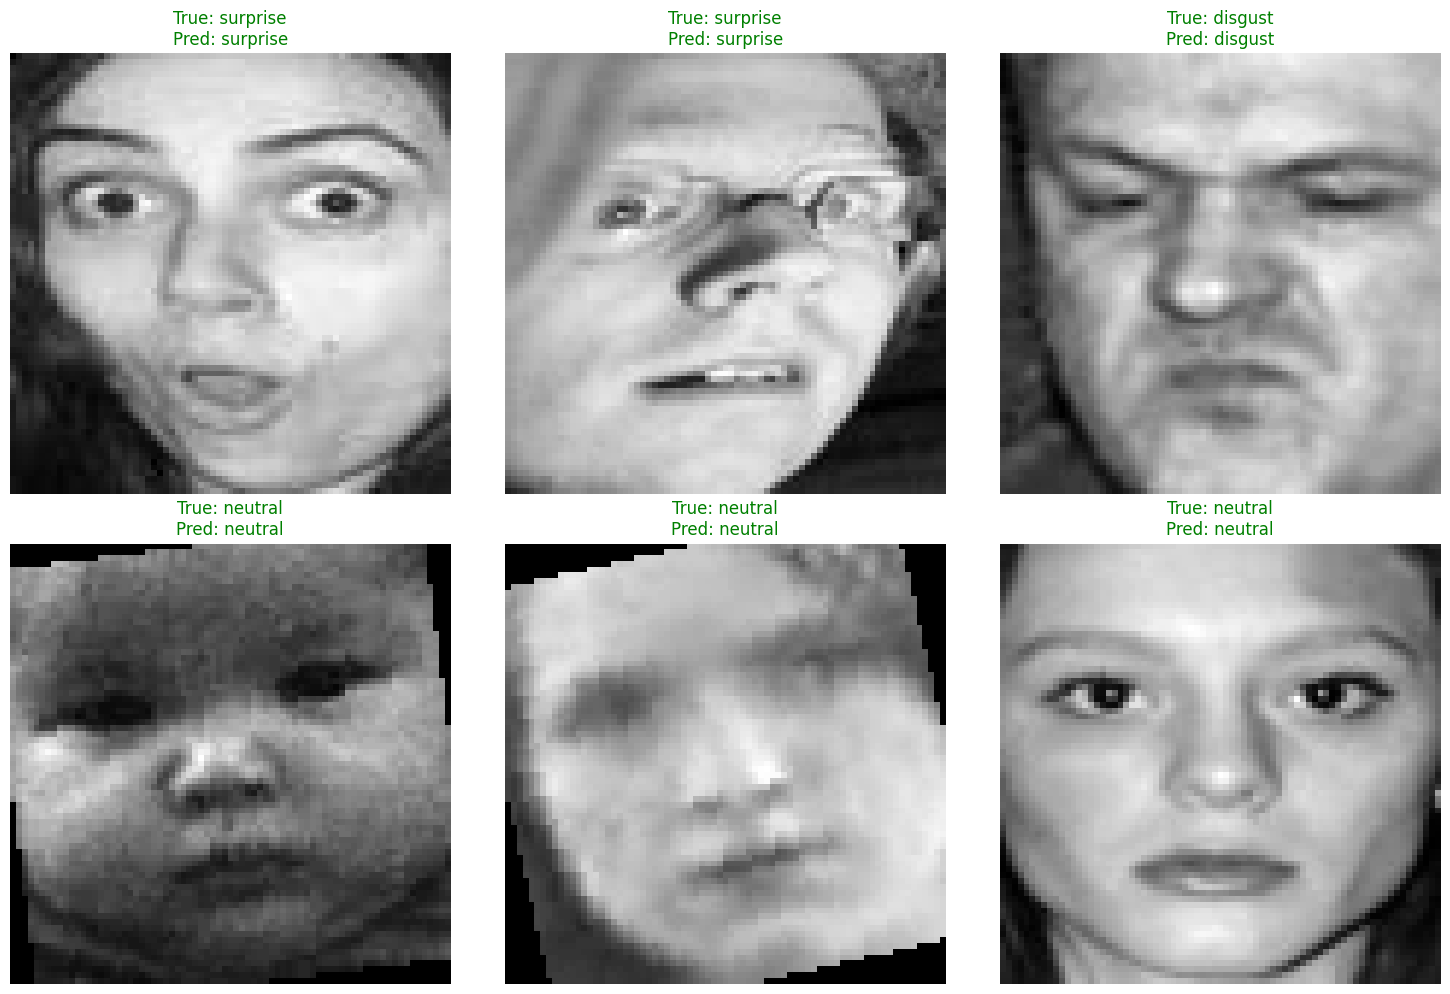

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(model, loader, class_names, num_images=6):

    # mode of working 
    model.eval()
    
    # 1. Get a random batch
    images, labels = next(iter(loader))
    
    # 2. Move to device and get predictions
    images_gpu = images.to(device)
    outputs = model(images_gpu)
    _, preds = torch.max(outputs, 1)
    
    # 3. Plotting
    plt.figure(figsize=(15, 10))
    for i in range(num_images):
        plt.subplot(2, 3, i + 1)
        
        # Convert grayscale tensor back to image format (H, W)
        img = images[i].squeeze().cpu().numpy()
        plt.imshow(img, cmap='gray')
        
        # Set label color: Green if correct, Red if wrong
        color = 'green' if preds[i] == labels[i] else 'red'
        
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}", 
                  color=color, fontsize=12)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_random_samples(model, test_loader, train_dataset.classes)

# save model wieghts 

In [14]:
torch.save(model.state_dict(), 'model_wieghts.pth')